# =df[df[

How are skills trending for Data Analysts on a monthly basis.

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [11]:
df_DA=df[df['job_title']=='Data analyst'].copy()
df_DA

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
386,Data Analyst,Data analyst,"Lugano, Switzerland",via Randstad,Full-time,False,Switzerland,2023-10-11 13:28:03,True,False,Switzerland,None,NaN,NaN,Randstad,[excel],{'analyst_tools': ['excel']}
524,Data Analyst,Data analyst,"Kyiv, Ukraine",via Robota.ua,Full-time,False,Ukraine,2023-07-11 13:47:33,True,False,Ukraine,None,NaN,NaN,"Fozzy Group, Логістика",None,None
652,Data Analyst,Data analyst,"Villeurbanne, France",via Jobijoba,Full-time,False,France,2023-11-24 13:16:41,True,False,France,None,NaN,NaN,Amiltone,"[sql, oracle, jira]","{'async': ['jira'], 'cloud': ['oracle'], 'prog..."
1198,Data Analyst,Data analyst,"Roanoke, TX",via Jobs Trabajo.org,Full-time,False,"Texas, United States",2023-12-21 13:01:01,False,False,United States,None,NaN,NaN,Deloitte,[windows],{'os': ['windows']}
1323,Data Analyst,Data analyst,France,via LinkedIn,Full-time,False,France,2023-05-10 13:28:32,False,False,France,None,NaN,NaN,Clémentine - Certified Search & Selection,"[sql, r, c#, javascript, html, css, python, sq...","{'analyst_tools': ['power bi', 'ssis', 'ssrs']..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
780790,Data Analyst,Data analyst,"Mexico City, CDMX, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-09 06:16:13,False,False,Mexico,None,NaN,NaN,Tata Consultancy Services,"[javascript, c#, python]","{'programming': ['javascript', 'c#', 'python']}"
781881,Data Analyst,Data analyst,Czechia,via Trabajo.org,Full-time,False,Czechia,2023-01-07 06:41:39,True,False,Czechia,None,NaN,NaN,LEDVANCE s.r.o.,"[sql, javascript, python, snowflake]","{'cloud': ['snowflake'], 'programming': ['sql'..."
782480,Data Analyst,Data analyst,Singapore,via Trabajo.org,Full-time,False,Singapore,2023-01-23 06:21:15,False,False,Singapore,None,NaN,NaN,CDG ZIG PTE. LTD.,"[sql, python, tableau]","{'analyst_tools': ['tableau'], 'programming': ..."
784163,Data Analyst,Data analyst,"Huizen, Netherlands",via Uitzendbureau.nl,Full-time,False,Netherlands,2023-01-25 06:25:26,True,False,Netherlands,None,NaN,NaN,Olympia,[power bi],{'analyst_tools': ['power bi']}


In [14]:

df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

In [15]:
df_DA_explode= df_DA.explode('job_skills')

df_DA_explode


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
386,Data Analyst,Data analyst,"Lugano, Switzerland",via Randstad,Full-time,False,Switzerland,2023-10-11 13:28:03,True,False,Switzerland,None,NaN,NaN,Randstad,excel,{'analyst_tools': ['excel']},10
524,Data Analyst,Data analyst,"Kyiv, Ukraine",via Robota.ua,Full-time,False,Ukraine,2023-07-11 13:47:33,True,False,Ukraine,None,NaN,NaN,"Fozzy Group, Логістика",None,None,7
652,Data Analyst,Data analyst,"Villeurbanne, France",via Jobijoba,Full-time,False,France,2023-11-24 13:16:41,True,False,France,None,NaN,NaN,Amiltone,sql,"{'async': ['jira'], 'cloud': ['oracle'], 'prog...",11
652,Data Analyst,Data analyst,"Villeurbanne, France",via Jobijoba,Full-time,False,France,2023-11-24 13:16:41,True,False,France,None,NaN,NaN,Amiltone,oracle,"{'async': ['jira'], 'cloud': ['oracle'], 'prog...",11
652,Data Analyst,Data analyst,"Villeurbanne, France",via Jobijoba,Full-time,False,France,2023-11-24 13:16:41,True,False,France,None,NaN,NaN,Amiltone,jira,"{'async': ['jira'], 'cloud': ['oracle'], 'prog...",11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782480,Data Analyst,Data analyst,Singapore,via Trabajo.org,Full-time,False,Singapore,2023-01-23 06:21:15,False,False,Singapore,None,NaN,NaN,CDG ZIG PTE. LTD.,tableau,"{'analyst_tools': ['tableau'], 'programming': ...",1
784163,Data Analyst,Data analyst,"Huizen, Netherlands",via Uitzendbureau.nl,Full-time,False,Netherlands,2023-01-25 06:25:26,True,False,Netherlands,None,NaN,NaN,Olympia,power bi,{'analyst_tools': ['power bi']},1
784249,Data Analyst,Data analyst,"Mexico City, CDMX, Mexico",via Trabajo.org,Full-time,False,Mexico,2023-01-09 06:16:30,False,False,Mexico,None,NaN,NaN,Tata Consultancy Services,javascript,"{'programming': ['javascript', 'c#', 'python']}",1
784249,Data Analyst,Data analyst,"Mexico City, CDMX, Mexico",via Trabajo.org,Full-time,False,Mexico,2023-01-09 06:16:30,False,False,Mexico,None,NaN,NaN,Tata Consultancy Services,c#,"{'programming': ['javascript', 'c#', 'python']}",1


In [16]:
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

df_DA_pivot

job_skills,airflow,airtable,alteryx,angular,asp.net,assembly,atlassian,aurora,aws,azure,...,unity,unix,vba,visio,visual basic,vue,webex,windows,word,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,9,4,10,0,0,0,0,1,9,13,...,0,1,5,4,0,1,2,0,12,0
2,0,0,4,0,0,0,0,0,3,9,...,0,0,2,1,0,2,0,1,7,0
3,0,0,5,0,0,0,0,0,7,3,...,0,0,1,1,2,1,0,0,10,0
4,1,0,3,0,0,0,0,0,4,1,...,3,2,5,3,2,2,0,0,5,0
5,2,0,3,0,0,0,0,0,0,2,...,0,0,4,1,1,1,0,0,4,0
6,4,0,3,1,0,1,0,0,2,4,...,0,2,5,2,0,1,0,1,4,0
7,3,0,0,0,1,0,1,0,8,6,...,0,1,8,3,1,1,0,0,10,0
8,0,0,5,0,0,0,3,1,10,12,...,0,2,6,1,1,0,0,1,21,3
9,0,0,4,1,0,0,0,1,17,12,...,0,1,4,6,0,1,0,4,9,0


In [18]:
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

df_DA_pivot

# Order columns by total count
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot
# Drop total row
df_DA_pivot = df_DA_pivot.drop('Total')

df_DA_pivot


job_skills,sql,excel,python,tableau,power bi,sas,r,word,powerpoint,oracle,...,flask,fortran,node.js,node,microsoft teams,sass,seaborn,symfony,terraform,trello
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,103,66,62,53,42,46,27,12,13,12,...,0,0,0,0,0,0,0,0,0,0
2,43,32,26,18,25,4,9,7,7,8,...,0,0,0,0,1,0,0,0,0,0
3,69,48,38,27,25,12,20,10,11,12,...,0,0,0,0,0,0,0,0,0,0
4,76,41,29,22,29,46,13,5,5,6,...,0,0,0,0,0,0,0,0,0,0
5,40,28,22,15,18,10,13,4,8,7,...,0,0,0,0,0,0,0,0,0,1
6,46,31,28,20,16,20,17,4,5,5,...,0,1,0,0,0,1,0,1,0,0
7,60,42,29,31,21,24,14,10,10,5,...,0,0,0,0,0,0,0,0,1,0
8,101,69,72,49,44,36,30,21,16,10,...,0,0,0,0,0,0,0,0,0,0
9,103,60,67,59,46,36,34,9,15,13,...,1,0,1,0,0,0,0,0,0,0


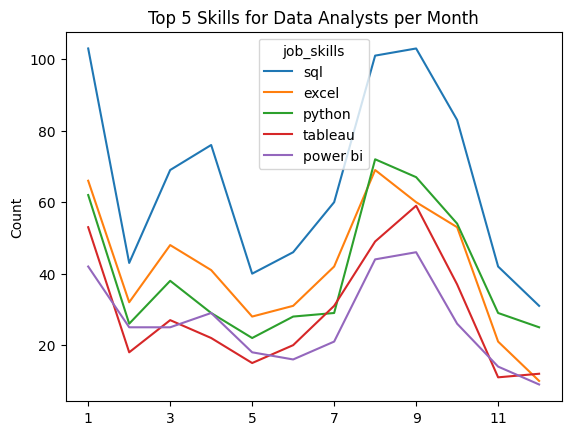

In [19]:
df_DA_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()